In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('train.csv')

In [3]:
data.head()

,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,0,37,70,36,Clayey,Sugarcane,36,4,5,28-28
1,1,27,69,65,Sandy,Millets,30,6,18,28-28
2,2,29,63,32,Sandy,Millets,24,12,16,17-17-17
3,3,35,62,54,Sandy,Barley,39,12,4,10-26-26
4,4,35,58,43,Red,Paddy,37,2,16,DAP


In [4]:
data.describe()

,id,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,31.503565,61.038912,45.184147,23.093808,9.478296,21.073227
std,216506.495284,4.025574,6.647695,11.794594,11.216125,5.765622,12.346831
min,0.000000,25.000000,50.000000,25.000000,4.000000,0.000000,0.000000
25%,187499.750000,28.000000,55.000000,35.000000,13.000000,4.000000,10.000000
50%,374999.500000,32.000000,61.000000,45.000000,23.000000,9.000000,21.000000
75%,562499.250000,35.000000,67.000000,55.000000,33.000000,14.000000,32.000000
max,749999.000000,38.000000,72.000000,65.000000,42.000000,19.000000,42.000000


In [18]:
#data.drop(columns=['Fertilizer Name'],inplace=True)
#data.drop(columns=['id'],inplace=True)

In [6]:
data['Crop Type'].value_counts()

Crop Type
Paddy          85754
Pulses         78180
Cotton         69171
Tobacco        68000
Wheat          66628
Millets        65291
Barley         65045
Sugarcane      64269
Oil seeds      64184
Maize          62569
Ground Nuts    60909
Name: count, dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.impute import SimpleImputer

In [39]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, f1_score

In [53]:
#encoder =LabelEncoder()
#soil_type = data['Soil Type']
#soil_type_encode = encoder.fit_transform(soil_type)


#from sklearn import preprocessing
#>>> le = preprocessing.LabelEncoder()
#>>> le.fit([1, 2, 2, 6])
#LabelEncoder()
#>>> le.classes_
#array([1, 2, 6])
#>>> le.transform([1, 1, 2, 6])
#array([0, 0, 1, 2]...)

In [54]:
#encoder.classes_

In [47]:
test_data.shape

(250000, 7)

In [46]:
X = data[['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']]
y = data['Crop Type']

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state=60, shuffle=True,)

In [49]:
#data['Soil Type'] = soil_type_encode

In [50]:
random_forest_model = RandomForestClassifier(n_estimators=150,random_state=62,verbose=0)

In [51]:
model = random_forest_model.fit(X_train, y_train)

In [24]:
test_data = pd.read_csv('test.csv')
test_data.drop(columns = ['id','Crop Type'],inplace=True)

In [25]:
soil_type_test = test_data['Soil Type']
soil_type_encoded = encoder.fit_transform(soil_type_test)
test_data['Soil Type'] = soil_type_encoded

In [55]:
y_pred = model.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.10372

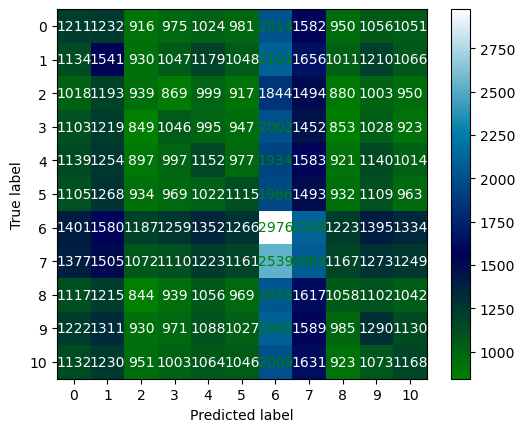

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='ocean')

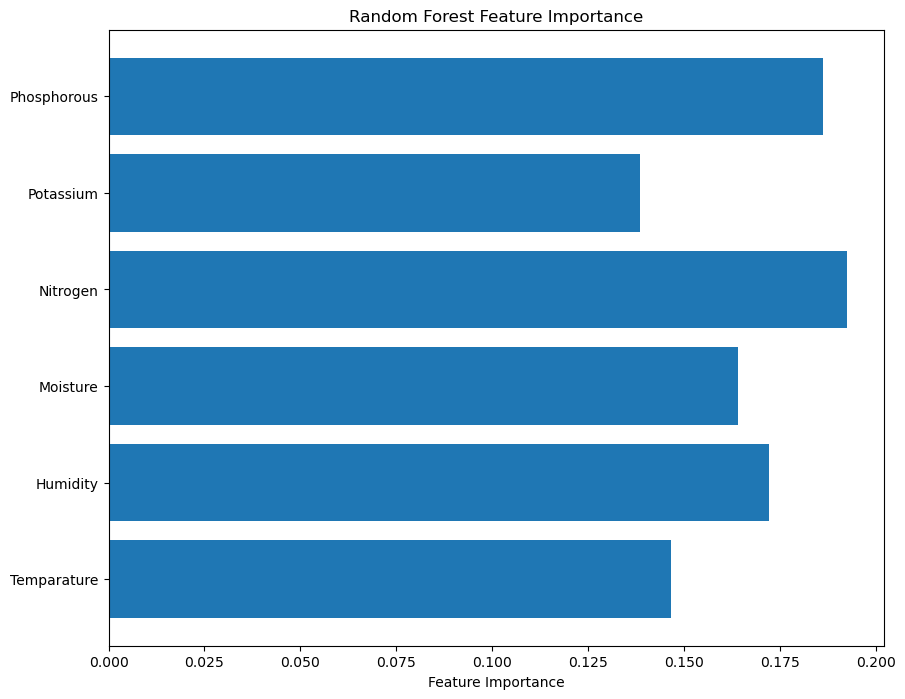

In [52]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 8))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=62), param_grid, cv=3, verbose=1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)


Fitting 3 folds for each of 36 candidates, totalling 108 fits
